In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from traffic_monitoring_ml.utils import load_pickle, load_json, save_pickle
from traffic_monitoring_ml.config import COLLISION_VALUE_MAP_PATH, CASUALTY_VALUE_MAP_PATH, VEHICLE_VALUE_MAP_PATH, X_TRAIN_PATH, Y_TRAIN_PATH, GROUPS_TRAIN_PATH, SELECTED_FEATURES_PATH, X_TEST_PATH, Y_TEST_PATH, CATBOOST_MODEL_PATH, MODELS_DIR, MODEL_METRICS_DIR

from pathlib import Path
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, recall_score, precision_score, precision_recall_curve, roc_curve, auc

import optuna
from optuna.samplers import TPESampler

In [3]:
casualty_value_map = load_pickle(Path(CASUALTY_VALUE_MAP_PATH))
vehicle_value_map = load_pickle(Path(VEHICLE_VALUE_MAP_PATH))
collision_value_map = load_pickle(Path(COLLISION_VALUE_MAP_PATH))

## Carga de datos y features seleccionadas

Cargamos train y test, aplicamos los mapas de valores y filtramos únicamente las
features seleccionadas en el notebook anterior. Esto asegura que el modelo final
se entrena exactamente con las mismas variables que se evaluaron durante la selección.

In [4]:
X_train = (pd.read_parquet(Path(X_TRAIN_PATH))
           .replace(casualty_value_map)
           .replace(collision_value_map)
           .replace(vehicle_value_map))
X_test = (pd.read_parquet(Path(X_TEST_PATH))
           .replace(casualty_value_map)
           .replace(collision_value_map)
           .replace(vehicle_value_map))

y_train = pd.read_parquet(Path(Y_TRAIN_PATH)).squeeze()
y_test = pd.read_parquet(Path(Y_TEST_PATH)).squeeze()

groups_train = pd.read_parquet(Path(GROUPS_TRAIN_PATH)).squeeze()

In [5]:
X_train.columns

Index(['casualty_class', 'sex_of_casualty', 'age_of_casualty',
       'age_band_of_casualty', 'pedestrian_location', 'pedestrian_movement',
       'car_passenger', 'bus_or_coach_passenger',
       'pedestrian_road_maintenance_worker', 'casualty_type',
       'casualty_imd_decile', 'casualty_injury_based', 'vehicle_type',
       'towing_and_articulation', 'vehicle_manoeuvre',
       'vehicle_direction_from', 'vehicle_direction_to',
       'vehicle_location_restricted_lane', 'junction_location',
       'skidding_and_overturning', 'hit_object_in_carriageway',
       'vehicle_leaving_carriageway', 'hit_object_off_carriageway',
       'first_point_of_impact', 'vehicle_left_hand_drive',
       'journey_purpose_of_driver', 'sex_of_driver', 'age_of_driver',
       'age_band_of_driver', 'driver_imd_decile', 'escooter_flag', 'longitude',
       'latitude', 'police_force', 'number_of_vehicles',
       'number_of_casualties', 'date', 'day_of_week', 'time',
       'first_road_class', 'road_type', '

In [6]:
selected_features = load_json(Path(SELECTED_FEATURES_PATH))
len(selected_features)

23

In [7]:
X_train = X_train[selected_features]
X_test = X_test[selected_features]

In [7]:
print(X_train.shape, X_test.shape)

(512334, 23) (128070, 23)


## Baseline cross validation

Antes de optimizar hiperparámetros, establecemos una línea base con `GroupKFold`
de 5 folds, respetando los grupos por `collision_index`. Usamos los hiperparámetros
por defecto del feature selection para tener un punto de referencia estable.

In [8]:
gkf = GroupKFold(n_splits=5)

cat_features = [col for col in X_train.columns if X_train[col].dtype in ['object', 'str']]

auc_results = []
for train_idx, val_idx in gkf.split(X_train, y_train, groups_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    eval_pool = Pool(X_val, y_val, cat_features=cat_features)

    model_cv = CatBoostClassifier(
        random_seed=42,
        iterations=1500,
        learning_rate=0.1,
        depth=8,
        verbose=100,
        eval_metric='AUC',
        task_type='GPU',
        devices='0',
        early_stopping_rounds=20,
        auto_class_weights='Balanced',
    )

    model_cv.fit(X_tr, y_tr, cat_features=cat_features, eval_set=eval_pool, use_best_model=True)

    auc_score = model_cv.get_best_score()['validation']['AUC']
    auc_results.append(auc_score)
    print(f"Fold AUC: {auc_score:.4f}")

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7295161	best: 0.7295161 (0)	total: 156ms	remaining: 3m 53s
100:	test: 0.7590827	best: 0.7590827 (100)	total: 11.9s	remaining: 2m 44s
200:	test: 0.7610639	best: 0.7610639 (200)	total: 23.3s	remaining: 2m 30s
300:	test: 0.7614445	best: 0.7614580 (291)	total: 34.8s	remaining: 2m 18s
400:	test: 0.7617053	best: 0.7617376 (391)	total: 46.8s	remaining: 2m 8s
bestTest = 0.7617376447
bestIteration = 391
Shrink model to first 392 iterations.
Fold AUC: 0.7617


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7247494	best: 0.7247494 (0)	total: 388ms	remaining: 9m 41s
100:	test: 0.7569486	best: 0.7569486 (100)	total: 12.7s	remaining: 2m 56s
200:	test: 0.7587910	best: 0.7587957 (196)	total: 25.4s	remaining: 2m 44s
300:	test: 0.7593900	best: 0.7594002 (297)	total: 38.3s	remaining: 2m 32s
bestTest = 0.7595814168
bestIteration = 355
Shrink model to first 356 iterations.
Fold AUC: 0.7596


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7256514	best: 0.7256514 (0)	total: 326ms	remaining: 8m 8s
100:	test: 0.7564239	best: 0.7564239 (100)	total: 13.2s	remaining: 3m 2s
200:	test: 0.7587457	best: 0.7587457 (200)	total: 26.7s	remaining: 2m 52s
300:	test: 0.7597407	best: 0.7597637 (293)	total: 40.7s	remaining: 2m 42s
bestTest = 0.7598981559
bestIteration = 310
Shrink model to first 311 iterations.
Fold AUC: 0.7599


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7232020	best: 0.7232020 (0)	total: 171ms	remaining: 4m 15s
100:	test: 0.7575109	best: 0.7575109 (100)	total: 13.4s	remaining: 3m 5s
200:	test: 0.7597049	best: 0.7597095 (199)	total: 27.2s	remaining: 2m 55s
300:	test: 0.7602679	best: 0.7602928 (296)	total: 41.4s	remaining: 2m 44s
bestTest = 0.7605520785
bestIteration = 345
Shrink model to first 346 iterations.
Fold AUC: 0.7606


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7251278	best: 0.7251278 (0)	total: 393ms	remaining: 9m 49s
100:	test: 0.7552201	best: 0.7552209 (99)	total: 13.6s	remaining: 3m 8s
200:	test: 0.7570072	best: 0.7570072 (200)	total: 27.6s	remaining: 2m 58s
bestTest = 0.757309854
bestIteration = 278
Shrink model to first 279 iterations.
Fold AUC: 0.7573


In [9]:
print(f'Baseline model CV AUC score mean: {np.array(auc_results).mean()}')
print(f'Baseline model CV STD: {np.array(auc_results).std()}')

Baseline model CV AUC score mean: 0.7598158299922944
Baseline model CV STD: 0.001454446706622714


## Optimización de hiperparámetros con Optuna

Usamos Optuna con el sampler TPE (Tree-structured Parzen Estimator) para buscar
eficientemente la mejor combinación de hiperparámetros. Para acelerar el proceso,
trabajamos sobre una muestra representativa del 20% del train, manteniendo la
estructura de grupos. Los parámetros explorados son:

- `learning_rate`: controla el tamaño del paso en el boosting.
- `depth`: profundidad máxima de los árboles.
- `l2_leaf_reg`: regularización L2 para evitar overfit.
- `bagging_temperature`: aleatoriedad en el bagging de muestras.
- `random_strength`: aleatoriedad en la selección de splits.

Se ejecutan 20 trials y se seleccionan los parámetros que maximizan el AUC en validación.

In [10]:
gss_sample = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
sample_idx, _ = next(gss_sample.split(X_train, y_train, groups_train))

X_sample = X_train.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]
groups_sample = groups_train.iloc[sample_idx]

def objective(trial):
    params = {
        'random_seed': 42,
        'iterations': 1500,
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 0, 1),
        'verbose': False,
        'eval_metric': 'AUC',
        'early_stopping_rounds': 20,
        'auto_class_weights': 'Balanced',
        'task_type': 'GPU',
        'devices': '0'
    }
    gkf_opt = GroupKFold(n_splits=2)
    auc_results = []
    for train_idx, val_idx in gkf_opt.split(X_sample, y_sample, groups_sample):
        X_tr, X_val = X_sample.iloc[train_idx], X_sample.iloc[val_idx]
        y_tr, y_val = y_sample.iloc[train_idx], y_sample.iloc[val_idx]

        eval_pool = Pool(X_val, y_val, cat_features=cat_features)

        model_opt = CatBoostClassifier(**params)
        model_opt.fit(X_tr, y_tr, cat_features=cat_features, eval_set=eval_pool, use_best_model=True)

        preds = model_opt.predict_proba(X_val)[:, 1]
        auc_results.append(roc_auc_score(y_val, preds))

    return np.array(auc_results).mean()

sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f"Best AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

[I 2026-05-13 19:50:08,987] A new study created in memory with name: no-name-5b64d8ee-8e0b-4096-9b61-d3a4d7806aa4


  0%|          | 0/20 [00:00<?, ?it/s]

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


[I 2026-05-13 19:51:13,486] Trial 0 finished with value: 0.7512027092371418 and parameters: {'learning_rate': 0.09781801964118501, 'depth': 10, 'l2_leaf_reg': 7.587945476302646, 'bagging_temperature': 0.5986584841970366, 'random_strength': 0.15601864044243652}. Best is trial 0 with value: 0.7512027092371418.


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


...

[I 2026-05-13 20:23:37,231] Trial 17 finished with value: 0.7534109054366167 and parameters: {'learning_rate': 0.0871416663260538, 'depth': 6, 'l2_leaf_reg': 4.689499927889351, 'bagging_temperature': 0.462114758401128, 'random_strength': 0.8320220814519674}. Best is trial 3 with value: 0.7535306692109416.


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


[I 2026-05-13 20:25:54,969] Trial 18 finished with value: 0.7533534147611258 and parameters: {'learning_rate': 0.06374872651534924, 'depth': 8, 'l2_leaf_reg': 7.03218473816225, 'bagging_temperature': 0.2512182634368739, 'random_strength': 0.3208501786198171}. Best is trial 3 with value: 0.7535306692109416.


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


[I 2026-05-13 20:27:25,689] Trial 19 finished with value: 0.750993215392876 and parameters: {'learning_rate': 0.12050320714646533, 'depth': 9, 'l2_leaf_reg': 3.102147164493913, 'bagging_temperature': 0.11190457068811277, 'random_strength': 0.5211725029161519}. Best is trial 3 with value: 0.7535306692109416.
Best AUC: 0.7535
Best params: {'learning_rate': 0.06945227129221505, 'depth': 6, 'l2_leaf_reg': 5.72280788469014, 'bagging_temperature': 0.43194501864211576, 'random_strength': 0.2912291401980419}


### Verificación de cross validation con los parámetros de Optuna

In [11]:
gkf_opt = GroupKFold(n_splits=5)
best_params = {
    'learning_rate': 0.05114503882083299,
    'depth': 7,
    'l2_leaf_reg': 3.6544467622105867,
    'bagging_temperature': 0.2922384655019864,
    'random_strength': 0.34251599373775665
}
cat_features = [col for col in X_train.columns if X_train[col].dtype in ['object', 'str']]
auc_results = []

for train_idx, val_idx in gkf_opt.split(X_train, y_train, groups_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    eval_pool = Pool(X_val, y_val, cat_features=cat_features)

    model_opt = CatBoostClassifier(
        **best_params,
        iterations=1500,
        random_seed=42,
        verbose=100,
        eval_metric='AUC',
        task_type='GPU',
        devices='0',
        early_stopping_rounds=20,
        auto_class_weights='Balanced',
    )
    model_opt.fit(X_tr, y_tr, cat_features=cat_features, eval_set=eval_pool, use_best_model=True)

    preds = model_opt.predict_proba(X_val)[:, 1]
    auc_results.append(roc_auc_score(y_val, preds))

print(f'Best hyperparam model CV AUC score mean: {np.array(auc_results).mean()}')
print(f'Best hyperparam model CV STD: {np.array(auc_results).std()}')

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7268497	best: 0.7268497 (0)	total: 470ms	remaining: 11m 45s
100:	test: 0.7553653	best: 0.7553653 (100)	total: 35.2s	remaining: 8m 8s
200:	test: 0.7593324	best: 0.7593324 (200)	total: 50s	remaining: 5m 22s
300:	test: 0.7609248	best: 0.7609248 (300)	total: 1m 5s	remaining: 4m 21s
400:	test: 0.7617369	best: 0.7617369 (400)	total: 1m 42s	remaining: 4m 41s
500:	test: 0.7621013	best: 0.7621125 (497)	total: 1m 57s	remaining: 3m 55s
bestTest = 0.7622970641
bestIteration = 574
Shrink model to first 575 iterations.


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7233884	best: 0.7233884 (0)	total: 367ms	remaining: 9m 10s
100:	test: 0.7527780	best: 0.7527780 (100)	total: 34.9s	remaining: 8m 3s
200:	test: 0.7565803	best: 0.7565803 (200)	total: 48.8s	remaining: 5m 15s
300:	test: 0.7581044	best: 0.7581044 (300)	total: 1m 2s	remaining: 4m 9s
400:	test: 0.7587425	best: 0.7587425 (400)	total: 1m 16s	remaining: 3m 30s
500:	test: 0.7592638	best: 0.7592694 (498)	total: 1m 31s	remaining: 3m 3s
600:	test: 0.7594728	best: 0.7594734 (598)	total: 1m 46s	remaining: 2m 39s
700:	test: 0.7597167	best: 0.7597167 (700)	total: 2m	remaining: 2m 17s
bestTest = 0.7597622275
bestIteration = 719
Shrink model to first 720 iterations.


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7219189	best: 0.7219189 (0)	total: 768ms	remaining: 19m 11s
100:	test: 0.7516591	best: 0.7516591 (100)	total: 15s	remaining: 3m 27s
200:	test: 0.7559976	best: 0.7559976 (200)	total: 27.8s	remaining: 2m 59s
300:	test: 0.7578338	best: 0.7578338 (300)	total: 41.2s	remaining: 2m 44s
400:	test: 0.7586887	best: 0.7586887 (400)	total: 54.5s	remaining: 2m 29s
500:	test: 0.7592952	best: 0.7592952 (500)	total: 1m 8s	remaining: 2m 15s
bestTest = 0.7596156299
bestIteration = 577
Shrink model to first 578 iterations.


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7200237	best: 0.7200237 (0)	total: 4s	remaining: 1h 39m 50s
100:	test: 0.7529329	best: 0.7529329 (100)	total: 34s	remaining: 7m 50s
200:	test: 0.7571011	best: 0.7571011 (200)	total: 46.8s	remaining: 5m 2s
300:	test: 0.7586637	best: 0.7586637 (300)	total: 1m	remaining: 3m 59s
400:	test: 0.7595995	best: 0.7595995 (400)	total: 1m 13s	remaining: 3m 21s
500:	test: 0.7601357	best: 0.7601357 (500)	total: 1m 27s	remaining: 2m 53s
600:	test: 0.7604116	best: 0.7604116 (600)	total: 1m 40s	remaining: 2m 30s
bestTest = 0.7606519759
bestIteration = 677
Shrink model to first 678 iterations.


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7215653	best: 0.7215653 (0)	total: 382ms	remaining: 9m 32s
100:	test: 0.7513506	best: 0.7513506 (100)	total: 38.3s	remaining: 8m 50s
200:	test: 0.7551726	best: 0.7551726 (200)	total: 55.7s	remaining: 6m
300:	test: 0.7566349	best: 0.7566349 (300)	total: 1m 9s	remaining: 4m 36s
400:	test: 0.7575687	best: 0.7575701 (399)	total: 1m 24s	remaining: 3m 52s
500:	test: 0.7580816	best: 0.7580816 (500)	total: 1m 42s	remaining: 3m 25s
600:	test: 0.7584061	best: 0.7584061 (600)	total: 1m 58s	remaining: 2m 57s
bestTest = 0.7585291862
bestIteration = 648
Shrink model to first 649 iterations.
Best hyperparam model CV AUC score mean: 0.7601712139009034
Best hyperparam model CV STD: 0.0012587803000960929


### Entrenar modelo final

In [9]:
gss_final = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss_final.split(X_train, y_train, groups_train))

X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

cat_features = [col for col in X_train.columns if X_train[col].dtype in ['object', 'str']]
eval_pool = Pool(X_val, y_val, cat_features=cat_features)

best_params = {
    'learning_rate': 0.05114503882083299,
    'depth': 7,
    'l2_leaf_reg': 3.6544467622105867,
    'bagging_temperature': 0.2922384655019864,
    'random_strength': 0.34251599373775665
}

model_final = CatBoostClassifier(
    **best_params,
    iterations=1500,
    random_seed=42,
    verbose=100,
    eval_metric='AUC',
    task_type='GPU',
    devices='0',
    early_stopping_rounds=10,
    auto_class_weights='Balanced',
)
model_final.fit(X_tr, y_tr, cat_features=cat_features, eval_set=eval_pool, use_best_model=True)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7251324	best: 0.7251324 (0)	total: 143ms	remaining: 3m 35s
100:	test: 0.7548120	best: 0.7548120 (100)	total: 10.8s	remaining: 2m 29s
200:	test: 0.7585841	best: 0.7585841 (200)	total: 21.1s	remaining: 2m 16s
300:	test: 0.7600989	best: 0.7600989 (300)	total: 31.1s	remaining: 2m 3s
400:	test: 0.7608482	best: 0.7608482 (400)	total: 41.3s	remaining: 1m 53s
500:	test: 0.7612709	best: 0.7612743 (498)	total: 51.8s	remaining: 1m 43s
bestTest = 0.7614067197
bestIteration = 537
Shrink model to first 538 iterations.


CatBoostClassifier(auto_class_weights='Balanced', bagging_temperature=0.2922384655019864, depth=7, devices='0', early_stopping_rounds=10, eval_metric='AUC', iterations=1500, l2_leaf_reg=3.6544467622105867, learning_rate=0.05114503882083299, random_seed=42, random_strength=0.34251599373775665, task_type='GPU', verbose=100)

In [10]:
pred_train_p = model_final.predict_proba(X_train)[:, 1]
pred_test_p = model_final.predict_proba(X_test)[:, 1]

pred_train = model_final.predict(X_train)
pred_test = model_final.predict(X_test)

### Evaluación del modelo

El modelo final tiene un AUC de 0.756 en test frente a 0.778 en train. La diferencia de 0.023 indica una generalización correcta sin mucho overfitting. Este resultado se ha obtenido respetando la estructura de grupos mediante GroupShuffleSplit, evitando que víctimas del mismo accidente aparecieran simultáneamente en train y test, lo que habría inflado las métricas.

Con el umbral por defecto el modelo detecta el 71.74% de los accidentes severos, con una precisión del 34.3%. De cada 3 alarmas de severidad alta, aproximadamente 2 son falsas alarmas. De 25.775 accidentes severos en test, el modelo falla en detectar 7.540.

In [11]:
print(f'AUC train: {roc_auc_score(y_train, pred_train_p)}')
print(f'AUC test: {roc_auc_score(y_test, pred_test_p)}')
print(f'AUC diff: {roc_auc_score(y_train, pred_train_p) - roc_auc_score(y_test, pred_test_p)}')
print()
print(f'TRAIN recall: {recall_score(y_train, pred_train)}')
print(f'TEST recall: {recall_score(y_test, pred_test)}')
print()
print(f'TRAIN precision: {precision_score(y_train, pred_train)}')
print(f'TEST precision: {precision_score(y_test, pred_test)}')
print()
print(classification_report(y_test, pred_test ))
print(confusion_matrix(y_test, pred_test))

AUC train: 0.7804423300008763
AUC test: 0.7564699204659466
AUC diff: 0.02397240953492963

TRAIN recall: 0.7454642063568737
TEST recall: 0.7140252182347235

TRAIN precision: 0.3609154435495187
TEST precision: 0.344734574607575

              precision    recall  f1-score   support

           0       0.90      0.66      0.76    102295
           1       0.34      0.71      0.46     25775

    accuracy                           0.67    128070
   macro avg       0.62      0.69      0.61    128070
weighted avg       0.79      0.67      0.70    128070

[[67313 34982]
 [ 7371 18404]]


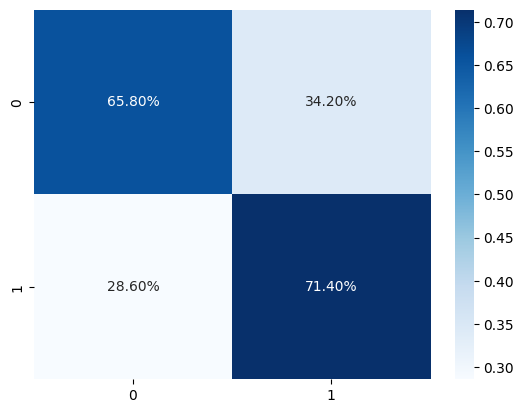

In [12]:
sns.heatmap(confusion_matrix(y_test, pred_test, normalize='true'), annot=True, cmap='Blues', fmt='.2%');

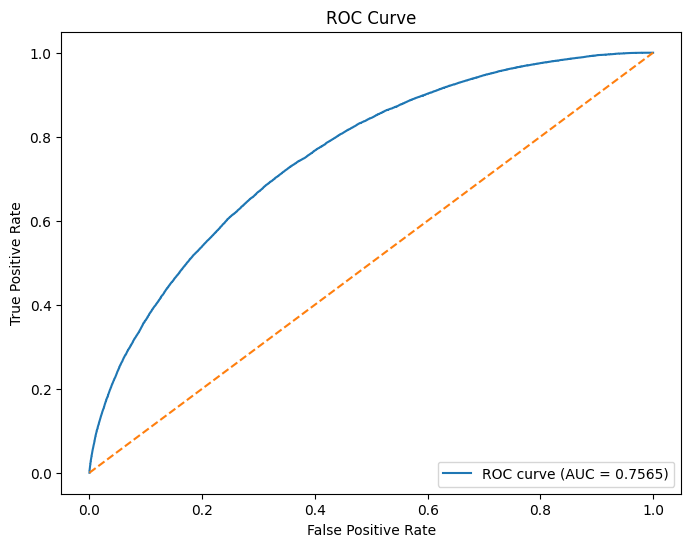

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, pred_test_p)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.show()

### Ajuste del umbral

El no detectar un accidente severo es mucho mas grave que el de enviar una ambulancia innecesariamente. Por este motivo se ajusta el umbral de clasificación a 0.247, con el objetivo de alcanzar un recall del 95% en la clase severa.
Esto significa que se enviarán recursos de más cuando no es necesario, pero se reduce considerablemente el riesgo de dejar sin atención inmediata a una víctima grave.

In [14]:
y_probs = model_final.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
target_recall = 0.95

idx = np.where(recalls >= target_recall)[0][-1]

best_threshold = thresholds[idx]
best_precision = precisions[idx]
best_recall = recalls[idx]

print(f'Threshold: {best_threshold}')
print(f'Recall: {best_recall}')
print(f'Precision: {best_precision}')

Threshold: 0.24707672984133108
Recall: 0.9500290979631426
Precision: 0.25199645988556374


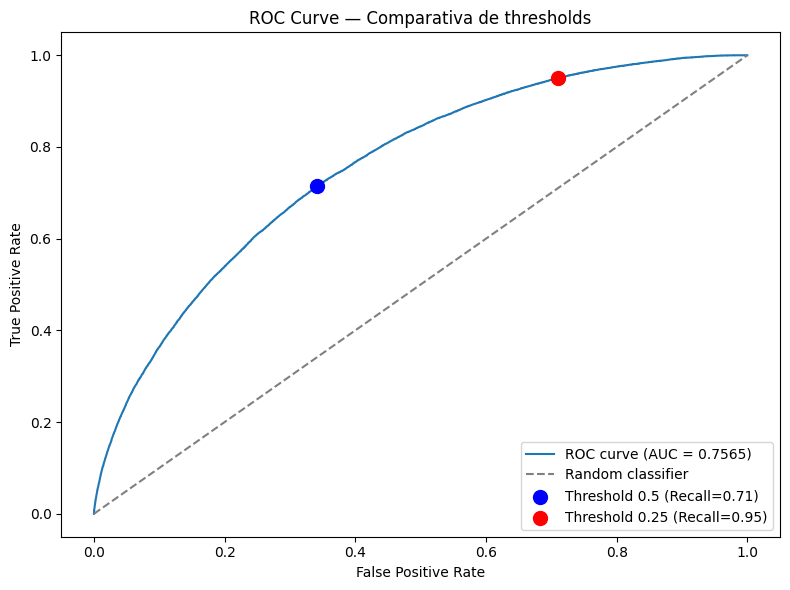

In [15]:
fpr, tpr, thresholds = roc_curve(y_test, pred_test_p)
roc_auc = auc(fpr, tpr)

# Encontrar el índice del threshold óptimo
optimal_idx = np.argmin(np.abs(thresholds - best_threshold))
optimal_fpr = fpr[optimal_idx]
optimal_tpr = tpr[optimal_idx]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')

# Punto del threshold por defecto (0.5)
default_idx = np.argmin(np.abs(thresholds - 0.5))
plt.scatter(fpr[default_idx], tpr[default_idx],
            color='blue', zorder=5, s=100,
            label=f'Threshold 0.5 (Recall={tpr[default_idx]:.2f})')

# Punto del threshold optimizado para recall
plt.scatter(optimal_fpr, optimal_tpr,
            color='red', zorder=5, s=100,
            label=f'Threshold {best_threshold:.2f} (Recall={optimal_tpr:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Comparativa de thresholds')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Guardar del modelo

Guardamos el modelo con el formato nativo de CatBoost, que preserva
toda la información necesaria para hacer inferencia sin necesidad de reentrenar.

In [16]:
model_final.save_model(str(Path(CATBOOST_MODEL_PATH)))

save_pickle(Path(MODELS_DIR / 'best_params.pkl'), best_params)